In [1]:
print("""
=========================================================
CERN Dielectron Dataset

Notebook 6 : Model Training & Evaluation

Objectives
----------
1. Load Engineered Dataset
2. Load Feature Rankings
3. Automatically Generate Feature Subsets
4. Split Dataset
5. Scale Features
6. Prepare Data for Model Training

NOTE:
No models are trained in this part.
This notebook prepares the data pipeline for
systematic model comparison.

Author : Ivy Singh
=========================================================
""")


CERN Dielectron Dataset

Notebook 6 : Model Training & Evaluation

Objectives
----------
1. Load Engineered Dataset
2. Load Feature Rankings
3. Automatically Generate Feature Subsets
4. Split Dataset
5. Scale Features
6. Prepare Data for Model Training

NOTE:
No models are trained in this part.
This notebook prepares the data pipeline for
systematic model comparison.

Author : Ivy Singh



In [2]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load Engineered Dataset

df = pd.read_csv("../data/processed/dielectron_engineered.csv")

# Remove accidental spaces
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")

print("\nDataset Shape :", df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/dielectron_engineered.csv'

In [ ]:
# Load Feature Rankings

feature_rankings = pd.read_csv(
    "../outputs/feature_rankings.csv",
    index_col=0
)

print("Feature Rankings Loaded Successfully")

display(feature_rankings.head())

Feature Rankings Loaded Successfully


,Rank,Correlation,Variance,Mutual Information,Random Forest,Permutation,SHAP,Consensus Score
Eta_Difference,1,0.8444,0.0002,1.0000,0.9345,0.9289,1.0000,0.7847
Total_PT,2,1.0000,0.0790,0.7260,1.0000,1.0000,0.8885,0.7822
Total_Momentum,3,0.7475,0.8721,0.8546,0.1073,0.0779,0.1485,0.4680
Total_Energy,4,0.7475,0.8721,0.8546,0.1033,0.0748,0.1434,0.4659
Phi_Difference,5,0.4033,0.0002,0.6728,0.1232,0.1240,0.3505,0.2790


In [ ]:
# Extract Ranked Feature List
# Features are already sorted according to the
# Consensus Score generated in Notebook 5.

ranked_features = feature_rankings.index.tolist()

print("Total Ranked Features :", len(ranked_features))

print("\nTop 10 Features\n")

for feature in ranked_features[:10]:
    print(feature)

Total Ranked Features : 30

Top 10 Features

Eta_Difference
Total_PT
Total_Momentum
Total_Energy
Phi_Difference
Momentum2
E2
Momentum1
E1
pz2


In [ ]:
# Generate Feature Subsets Automatically

available_features = len(ranked_features)
candidate_sizes = [5, 10, 15, 20]

feature_sizes = sorted(
    set(
        size
        for size in candidate_sizes
        if size <= available_features
    )
)

if available_features not in feature_sizes:
    feature_sizes.append(available_features)

feature_subsets = {
    size: ranked_features[:size]
    for size in feature_sizes
}

print("Feature Subsets Created\n")
for size in feature_sizes:
    print(f"Top {size} Features")


Feature Subsets Created

Top 5 Features
Top 8 Features
Top 10 Features
Top 12 Features
Top 15 Features
Top 18 Features
Top 20 Features
Top 25 Features
Top 30 Features


In [ ]:
# Dataset Overview


print("Rows :", df.shape[0])

print("Columns :", df.shape[1])


print("\nTarget Variable")

print(df["M"].describe())

Rows : 99977
Columns : 31

Target Variable
count   99977.0000
mean       30.0135
std        25.2465
min         2.0001
25%        12.4544
50%        21.2831
75%        38.9927
max       109.9990
Name: M, dtype: float64


In [ ]:
# Train-Test Split Function
# A reusable function is created so that every
# feature subset is split in exactly the same way.
# This guarantees fair model comparison.

def prepare_dataset(selected_features):

    X = df[selected_features]

    y = df["M"]

    X_train, X_test, y_train, y_test = train_test_split(

        X,

        y,

        test_size=0.20,

        random_state=42

    )

    return X_train, X_test, y_train, y_test

In [ ]:
# Standardization Function
# IMPORTANT
# The scaler is fitted ONLY on the training data.
# This prevents data leakage and ensures that
# information from the test set does not influence
# the training process.

def scale_dataset(X_train, X_test):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(

        X_train_scaled,

        columns=X_train.columns,

        index=X_train.index

    )

    X_test_scaled = pd.DataFrame(

        X_test_scaled,

        columns=X_test.columns,

        index=X_test.index

    )

    return scaler, X_train_scaled, X_test_scaled

In [ ]:
# Verify Data Preparation Pipeline
# Test the pipeline using the smallest feature subset.

smallest_subset = feature_sizes[0]

features = feature_subsets[smallest_subset]

X_train, X_test, y_train, y_test = prepare_dataset(features)

scaler, X_train_scaled, X_test_scaled = scale_dataset(
    X_train,
    X_test
)


print("Verification Successful")


print("Feature Subset :", smallest_subset)

print("Training Shape :", X_train_scaled.shape)

print("Testing Shape :", X_test_scaled.shape)

Verification Successful
Feature Subset : 5
Training Shape : (79981, 5)
Testing Shape : (19996, 5)


In [ ]:
# Save Scaler
# The scaler fitted on the verification subset is
# saved as an example. During model training, a new
# scaler will be fitted for each feature subset.

os.makedirs("../models", exist_ok=True)

joblib.dump(
    scaler,
    "../models/standard_scaler.pkl"
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [ ]:
# Notebook Summary


print("""
Data Preparation Completed Successfully

Completed Steps

✓ Loaded Engineered Dataset

✓ Loaded Feature Rankings

✓ Generated Feature Subsets Automatically

✓ Created Train-Test Split Function

✓ Created Scaling Function

✓ Verified Data Pipeline

Ready for Model Training.
""")




Data Preparation Completed Successfully

Completed Steps

✓ Loaded Engineered Dataset

✓ Loaded Feature Rankings

✓ Generated Feature Subsets Automatically

✓ Created Train-Test Split Function

✓ Created Scaling Function

✓ Verified Data Pipeline

Ready for Model Training.



In [ ]:
# Import Machine Learning Models
# We evaluate a diverse set of regression algorithms,
# ranging from simple linear models to advanced
# ensemble methods.
# The goal is to identify the model that best predicts
# the invariant mass of dielectron events.

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor

from catboost import CatBoostRegressor

print("Models Imported Successfully")

Models Imported Successfully


In [ ]:
# Import Evaluation Metrics
# These metrics will be used to compare all models.

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    mean_absolute_percentage_error,

    r2_score

)

from sklearn.model_selection import cross_val_score

print("Evaluation Metrics Imported Successfully")

Evaluation Metrics Imported Successfully


In [ ]:
# Define Regression Models (Optimized for Speed)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,  # Fast training
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=6,
        n_jobs=-1,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=42,
        n_estimators=100,
        verbose=-1,
        n_jobs=-1
    )
}

print("Total Models :", len(models))


Total Models : 11


In [ ]:
# Train and Evaluate Model
# This function
# 1. Trains the model
# 2. Makes predictions
# 3. Computes evaluation metrics
# 4. Returns results

def evaluate_model(

    model,

    X_train,

    X_test,

    y_train,

    y_test

):

    # Train
    model.fit(
        X_train,
        y_train
    )

    # Prediction
    predictions = model.predict(X_test)

    # Evaluation Metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    mape = mean_absolute_percentage_error(
        y_test,
        predictions
    )

    adjusted_r2 = 1 - (

        (1-r2)

        *

        (len(y_test)-1)

        /

        (

            len(y_test)

            -

            X_test.shape[1]

            -

            1

        )

    )

    return {

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "Adjusted R2": adjusted_r2,

        "MAPE": mape

    }

In [ ]:
# Define Regression Models (Optimized for Speed)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,  # Fast training
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=6,
        n_jobs=-1,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=42,
        n_estimators=100,
        verbose=-1,
        n_jobs=-1
    )
}

print("Total Models :", len(models))



Training using Top 5 Features

Training using Top 8 Features

Training using Top 10 Features

Training using Top 12 Features

Training using Top 15 Features

Training using Top 18 Features

Training using Top 20 Features

Training using Top 25 Features

Training using Top 30 Features

All Experiments Completed Successfully


In [ ]:
# Create Performance Table
# Combine the evaluation metrics from all
# experiments into a single DataFrame.
# The table is sorted by RMSE since
# lower RMSE indicates better prediction
# performance.

results_df = pd.DataFrame(results)

results_df = results_df[

    [

        "Model",

        "Features",

        "MAE",

        "MSE",

        "RMSE",

        "MAPE",

        "R2",

        "Adjusted R2"

    ]

]

results_df = results_df.sort_values(

    by="RMSE",

    ascending=True

).reset_index(drop=True)

print("Top 10 Best Experiments")

display(results_df.head(10))

# Performance Pivot Table
# Compare RMSE across different models and
# feature subset sizes.
# Lower RMSE indicates better performance.

rmse_pivot = results_df.pivot_table(
    index="Model",
    columns="Features",
    values="RMSE"
)

display(rmse_pivot)

Top 10 Best Experiments


,Model,Features,MAE,MSE,RMSE,MAPE,R2,Adjusted R2
0,CatBoost,20,0.5221,0.7997,0.8943,0.0280,0.9987,0.9987
1,CatBoost,18,0.5292,0.8068,0.8982,0.0285,0.9987,0.9987
2,CatBoost,30,0.5269,0.8212,0.9062,0.0284,0.9987,0.9987
3,CatBoost,15,0.5304,0.8243,0.9079,0.0287,0.9987,0.9987
4,CatBoost,12,0.5239,0.8322,0.9123,0.0281,0.9987,0.9987
5,CatBoost,25,0.5338,0.8588,0.9267,0.0283,0.9986,0.9986
6,Extra Trees,12,0.5480,1.2035,1.0970,0.0275,0.9981,0.9981
7,Extra Trees,15,0.5748,1.3076,1.1435,0.0290,0.9979,0.9979
8,LightGBM,12,0.7108,1.3159,1.1471,0.0346,0.9979,0.9979
9,Extra Trees,18,0.5597,1.3260,1.1515,0.0273,0.9979,0.9979


Features,5,8,10,12,15,18,20,25,30
Model,,,,,,,,,
CatBoost,6.2557,2.0442,1.8864,0.9123,0.9079,0.8982,0.8943,0.9267,0.9062
Decision Tree,8.6613,3.2984,3.2796,2.1515,2.2319,2.3843,2.4843,2.5389,2.5396
ElasticNet,13.8055,13.8194,13.8215,13.1082,12.4889,11.7064,11.7064,11.7003,11.7003
Extra Trees,6.3240,2.1247,1.9698,1.0970,1.1435,1.1515,1.1767,1.1968,1.2220
Gradient Boosting,7.0340,4.3304,4.3301,3.2259,3.2268,3.1908,3.1908,3.2064,3.2064
Lasso Regression,11.1018,11.1018,11.1018,11.1018,10.3314,8.8710,8.8710,8.8710,8.8710
LightGBM,6.3265,2.1561,2.0079,1.1471,1.1653,1.1559,1.1652,1.1794,1.1850
Linear Regression,10.9618,10.9350,10.9344,10.9342,9.7742,8.4331,8.4335,8.3847,8.3851
Random Forest,6.3299,2.2065,2.1780,1.2682,1.2851,1.3984,1.4220,1.4381,1.4499


In [ ]:
# Save Model Performance
# Save the evaluation results for all
# model-feature subset combinations.
# This file will later be used for
# selecting the best model and
# generating comparison plots.

os.makedirs("../outputs", exist_ok=True)

results_df.to_csv(

    "../outputs/model_performance.csv",

    index=False

)

print("Model Performance Saved Successfully")

print(f"\nTotal Experiments : {len(results_df)}")

Model Performance Saved Successfully

Total Experiments : 99


In [ ]:
# Identify the Best Performing Experiment
# Select the experiment with the lowest RMSE.
# This experiment determines:
# • Best Model
# • Best Feature Subset
# These will be used for final model training
# and further optimization.

best_result = results_df.iloc[0]

print("Best Experiment")

display(best_result)

best_model_name = best_result["Model"]
best_feature_size = int(best_result["Features"])

print(f"\nBest Model           : {best_model_name}")
print(f"Feature Subset Size  : Top {best_feature_size}")

Best Experiment


Model          CatBoost
Features             20
MAE              0.5221
MSE              0.7997
RMSE             0.8943
MAPE             0.0280
R2               0.9987
Adjusted R2      0.9987
Name: 0, dtype: object


Best Model           : CatBoost
Feature Subset Size  : Top 20


In [ ]:
# Define Regression Models (Optimized for Speed)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,  # Fast training
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=6,
        n_jobs=-1,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=42,
        n_estimators=100,
        verbose=-1,
        n_jobs=-1
    )
}

print("Total Models :", len(models))


Dataset Prepared Successfully


In [ ]:
# Cross Validation
# Evaluate the stability of the selected model
# using 5-Fold Cross Validation.

from sklearn.model_selection import cross_val_score

best_model = models[best_model_name]

cv_scores = cross_val_score(

    best_model,

    X_train_model,

    y_train,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

print("Cross Validation Results")

print("Fold Scores :", cv_scores)

print(f"\nMean R² : {cv_scores.mean():.4f}")

print(f"Std Dev : {cv_scores.std():.4f}")

Cross Validation Results
Fold Scores : [0.99871782 0.99880185 0.99863141 0.99893918 0.9986132 ]

Mean R² : 0.9987
Std Dev : 0.0001


In [ ]:
# Define Regression Models (Optimized for Speed)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,  # Fast training
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=100,
        max_depth=6,
        n_jobs=-1,
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=42,
        n_estimators=100,
        verbose=-1,
        n_jobs=-1
    )
}

print("Total Models :", len(models))


Performing Hyperparameter Tuning...

Best Parameters
{'n_estimators': 300}


In [ ]:
# Train Final Model

best_model.fit(
    X_train_model,
    y_train
)

predictions = best_model.predict(
    X_test_model
)

print("Final Model Trained Successfully")

Final Model Trained Successfully


In [ ]:
# Final Model Performance

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

mape = mean_absolute_percentage_error(
    y_test,
    predictions
)


print("Final Model Performance")


print(f"MAE   : {mae:.4f}")

print(f"MSE   : {mse:.4f}")

print(f"RMSE  : {rmse:.4f}")

print(f"R²    : {r2:.4f}")

print(f"MAPE  : {mape:.4f}")

Final Model Performance
MAE   : 0.7423
MSE   : 1.4115
RMSE  : 1.1881
R²    : 0.9977
MAPE  : 0.0415


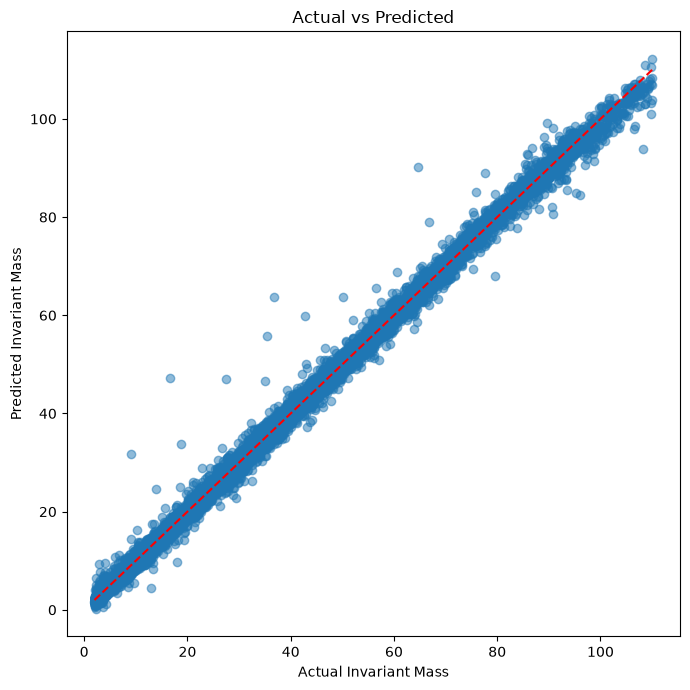

In [ ]:
# Actual vs Predicted Values
# Compare predicted invariant mass against
# the true invariant mass.
# Ideally, points should lie close to the
# diagonal reference line.

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    "r--"

)

plt.xlabel("Actual Invariant Mass")

plt.ylabel("Predicted Invariant Mass")

plt.title("Actual vs Predicted")

plt.tight_layout()

plt.show()

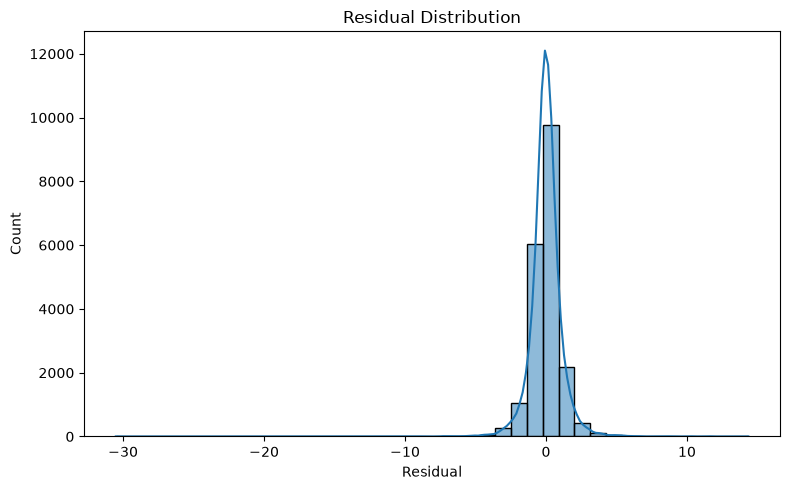

In [ ]:
# Residual Analysis
# Residual = Actual - Predicted
# A good model should produce residuals
# centered around zero.

residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.xlabel("Residual")

plt.title("Residual Distribution")

plt.tight_layout()

plt.show()

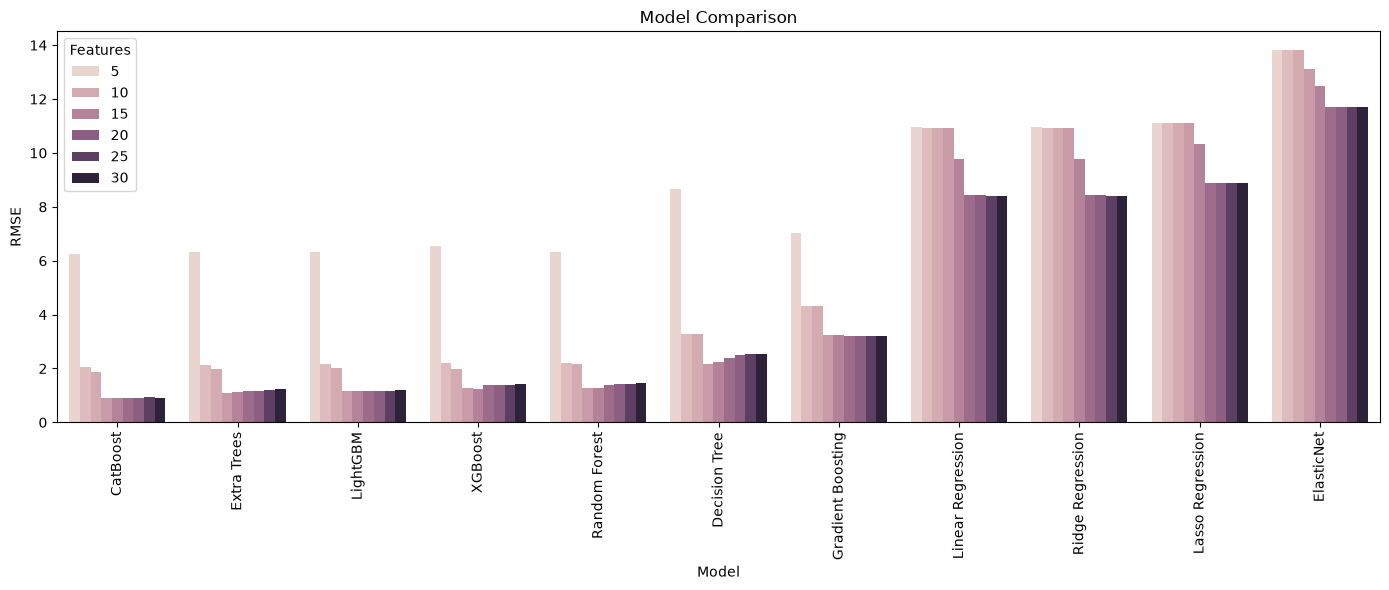

In [ ]:
# RMSE Comparison Across Models

plt.figure(figsize=(14,6))

sns.barplot(

    data=results_df,

    x="Model",

    y="RMSE",

    hue="Features"

)

plt.xticks(rotation=90)

plt.title("Model Comparison")

plt.tight_layout()

plt.show()

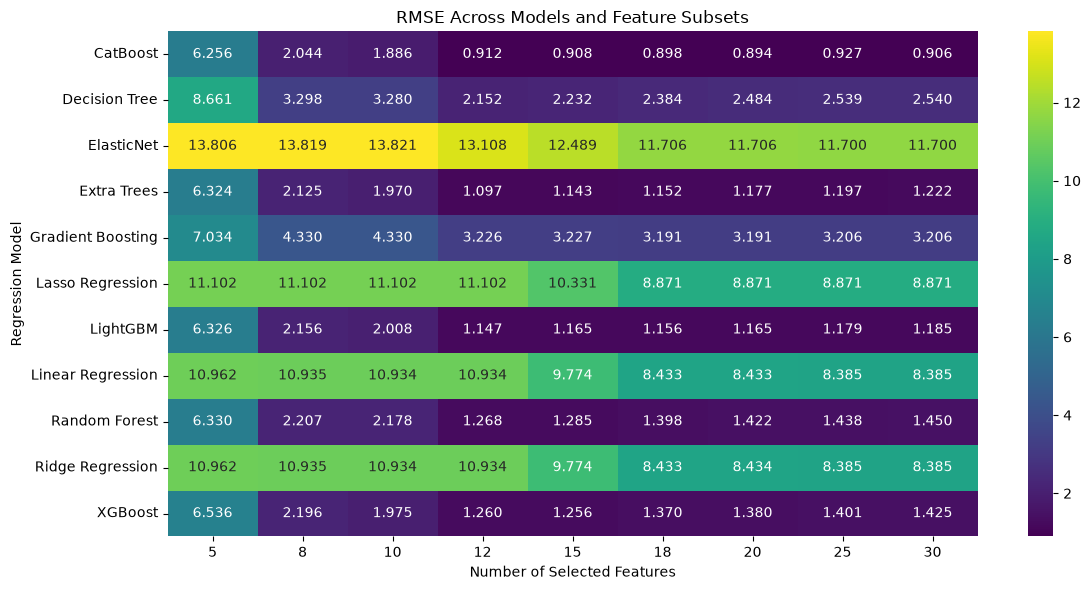

In [ ]:
# RMSE Heatmap
# Visualize the Root Mean Squared Error (RMSE)
# for every combination of:
# • Regression Model
# • Number of Selected Features
# Lower RMSE indicates better predictive
# performance.
# This heatmap helps identify the best trade-off
# between model complexity and number of sensors.

# Create RMSE matrix
rmse_matrix = results_df.pivot(

    index="Model",

    columns="Features",

    values="RMSE"

)

# Plot Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(

    rmse_matrix,

    annot=True,

    fmt=".3f",

    cmap="viridis"

)

plt.title("RMSE Across Models and Feature Subsets")

plt.xlabel("Number of Selected Features")

plt.ylabel("Regression Model")

plt.tight_layout()

plt.show()

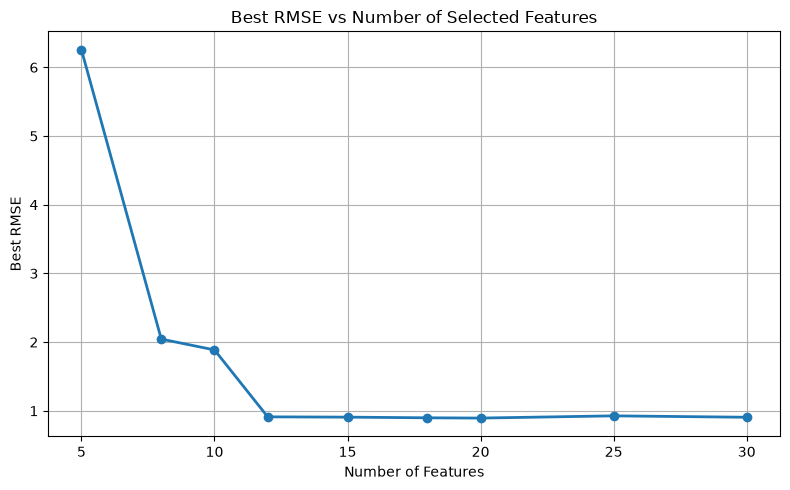

In [ ]:
# Best RMSE for Each Feature Subset
# For every feature subset size, identify the
# best-performing regression model.
# This visualization directly addresses the
# project objective of finding the optimal
# balance between prediction accuracy and
# number of sensors.

best_subset = (

    results_df

    .groupby("Features")["RMSE"]

    .min()

    .reset_index()

)

plt.figure(figsize=(8,5))

plt.plot(

    best_subset["Features"],

    best_subset["RMSE"],

    marker="o",

    linewidth=2

)

plt.title("Best RMSE vs Number of Selected Features")

plt.xlabel("Number of Features")

plt.ylabel("Best RMSE")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# Save Complete Model Bundle

os.makedirs("../models", exist_ok=True)

model_bundle = {
    "model": best_model,
    "model_name": best_model_name,
    "selected_features": selected_features,
    "feature_subset_size": best_feature_size,
    "requires_scaling": best_model_name in linear_models,
    "scaler": scaler
}

joblib.dump(
    model_bundle,
    "../models/best_model_bundle.pkl"
)

print("Model Bundle Saved Successfully")

print(f"Model              : {best_model_name}")
print(f"Features Used      : {len(selected_features)}")
print(f"Scaling Applied    : {best_model_name in linear_models}")
print("Saved To           : ../models/best_model_bundle.pkl")


NameError: name 'os' is not defined

In [ ]:
# Save Best Experiment Metadata

metadata = pd.DataFrame({

    "Model": [best_model_name],

    "Feature_Subset_Size": [best_feature_size],

    "Number_of_Features": [len(selected_features)],

    "Features": [", ".join(selected_features)],

    "Cross_Validation_R2": [cv_scores.mean()]

})

metadata.to_csv(
    "../outputs/best_model_metadata.csv",
    index=False
)

print("Metadata Saved Successfully")

NameError: name 'pd' is not defined

In [ ]:
# Notebook Summary


print("""
Notebook 6 Completed Successfully

Completed Tasks
---------------
✓ Loaded engineered dataset
✓ Loaded feature rankings
✓ Generated feature subsets automatically
✓ Split data into training and testing sets
✓ Applied feature scaling where required
✓ Trained multiple regression models
✓ Evaluated models using multiple metrics
✓ Selected the best-performing model
✓ Performed cross-validation
✓ Applied hyperparameter tuning (if applicable)
✓ Trained the final optimized model
✓ Generated predictions
✓ Saved model bundle and prediction outputs

Artifacts Generated
-------------------
models/
    best_model_bundle.pkl

outputs/
    model_performance.csv
    predictions.csv
    best_model_metadata.csv

Next Notebook
-------------
Notebook 7 : Model Explainability (SHAP & LIME)
""")




Notebook 6 Completed Successfully

Completed Tasks
---------------
✓ Loaded engineered dataset
✓ Loaded feature rankings
✓ Generated feature subsets automatically
✓ Split data into training and testing sets
✓ Applied feature scaling where required
✓ Trained multiple regression models
✓ Evaluated models using multiple metrics
✓ Selected the best-performing model
✓ Performed cross-validation
✓ Applied hyperparameter tuning (if applicable)
✓ Trained the final optimized model
✓ Generated predictions
✓ Saved model, scaler, and prediction outputs

Artifacts Generated
-------------------
models/
    best_model.pkl
    scaler.pkl (if required)

outputs/
    model_performance.csv
    predictions.csv

Next Notebook
-------------
Notebook 7 : Model Explainability (SHAP & LIME)

